# Plot wind clusters from Galveston station wind data

C:\Users\msmillan\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


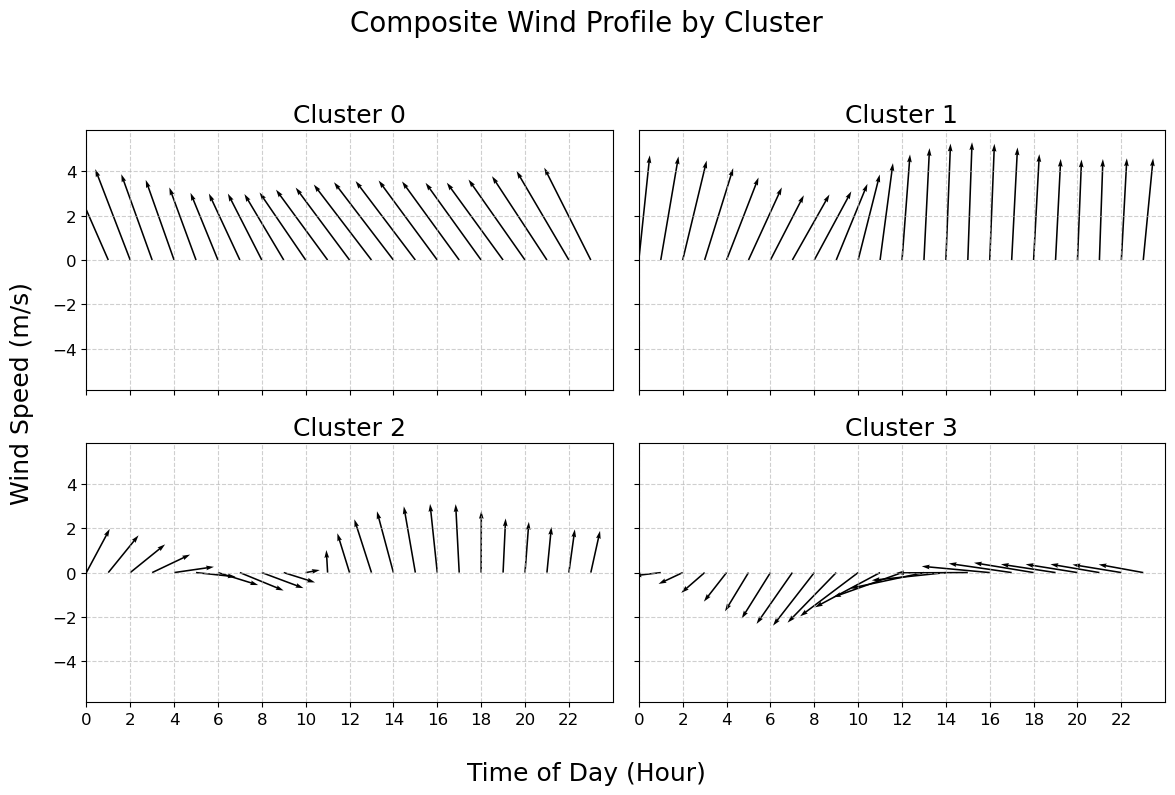

Saved: wind_profile_processed_clusters_2x2.png


In [1]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Plot style (match your previous formatting)
# =========================
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 16,
    "figure.titlesize": 16
})

# =========================
# Settings
# =========================
clusters = [0, 1, 2, 3]
out_png = "wind_profile_processed_clusters_2x2.png"

# =========================
# Pass 1: global max wind speed for consistent y-limits
# =========================
max_wind_speeds = []
for cluster in clusters:
    df = pd.read_csv(f"composite_processed_wind_cluster_{cluster}.csv")
    ws = np.sqrt(df["U"]**2 + df["V"]**2)
    max_wind_speeds.append(ws.max())

global_max = float(np.max(max_wind_speeds))

# (optional) pad so arrows don't touch edges
ylim = global_max * 1.10

# =========================
# Plot 2x2
# =========================
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, cluster in zip(axes, clusters):
    df = pd.read_csv(f"composite_processed_wind_cluster_{cluster}.csv")

    # Wind speed
    df["Wind_Speed_ms"] = np.sqrt(df["U"]**2 + df["V"]**2)

    # Wind direction (deg) computed same way you did
    df["Wind_Direction"] = np.degrees(np.arctan2(df["U"], df["V"])) % 360
    angle_rad = np.radians(df["Wind_Direction"])

    # Arrow components
    u_arrow = df["Wind_Speed_ms"] * np.sin(angle_rad)  # x-component
    v_arrow = df["Wind_Speed_ms"] * np.cos(angle_rad)  # y-component

    # Quiver at y=0
    ax.quiver(
        df["hour"], np.zeros_like(df["hour"]),
        u_arrow, v_arrow,
        scale=1, angles="xy", scale_units="xy",
        width=0.003
    )

    ax.set_title(f"Cluster {cluster}")
    ax.set_xlim(0, 23.99)
    ax.set_ylim(-ylim, ylim)
    ax.set_xticks(np.arange(0, 24, 2))
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.tick_params(axis="both")

# Shared labels (cleaner for 2x2)
fig.supxlabel("Time of Day (Hour)", fontsize=18)
fig.supylabel("Wind Speed (m/s)", fontsize=18)
fig.suptitle("Composite Wind Profile by Cluster", fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved: {out_png}")
